In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("lending_club_loan_two.csv")

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

# Data Preprocessing

In [5]:
columns_to_drop = [
    'emp_title',
    'title',
    'address',
    'issue_d',
    'earliest_cr_line',
    'grade',
    'sub_grade',
    'purpose',
    'initial_list_status',
    'application_type'
]

df.drop(columns=columns_to_drop, axis=1, inplace=True)


In [6]:

print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   emp_length            377729 non-null  object 
 5   home_ownership        396030 non-null  object 
 6   annual_inc            396030 non-null  float64
 7   verification_status   396030 non-null  object 
 8   loan_status           396030 non-null  object 
 9   dti                   396030 non-null  float64
 10  open_acc              396030 non-null  float64
 11  pub_rec               396030 non-null  float64
 12  revol_bal             396030 non-null  float64
 13  revol_util            395754 non-null  float64
 14  total_acc             396030 non-null  float64
 15  

In [8]:
df.head()

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,10000.0,36 months,11.44,329.48,10+ years,RENT,117000.0,Not Verified,Fully Paid,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0
1,8000.0,36 months,11.99,265.68,4 years,MORTGAGE,65000.0,Not Verified,Fully Paid,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0
2,15600.0,36 months,10.49,506.97,< 1 year,RENT,43057.0,Source Verified,Fully Paid,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0
3,7200.0,36 months,6.49,220.65,6 years,RENT,54000.0,Not Verified,Fully Paid,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0
4,24375.0,60 months,17.27,609.33,9 years,MORTGAGE,55000.0,Verified,Charged Off,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0


In [9]:
#missing values
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
emp_length,18301
home_ownership,0
annual_inc,0
verification_status,0
loan_status,0
dti,0


In [10]:
df['emp_length'] = df['emp_length'].str.replace(' years', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace(' year', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace('< 1', '0', regex=False)
df['emp_length'] = df['emp_length'].str.replace('10+', '10', regex=False)

df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

In [11]:
df['emp_length'].fillna(df['emp_length'].median(), inplace=True)

/tmp/ipykernel_9607/2567337395.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length'].fillna(df['emp_length'].median(), inplace=True)


In [12]:
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)

/tmp/ipykernel_9607/3900993684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['revol_util'].fillna(df['revol_util'].median(), inplace=True)


In [13]:
df['pub_rec_bankruptcies'].fillna(0, inplace=True)

/tmp/ipykernel_9607/2234613327.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pub_rec_bankruptcies'].fillna(0, inplace=True)


In [14]:
df['mort_acc'].fillna(0, inplace=True)

/tmp/ipykernel_9607/3475710510.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mort_acc'].fillna(0, inplace=True)


In [15]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0
loan_status,0
dti,0


In [16]:
df.head()

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,10000.0,36 months,11.44,329.48,10.0,RENT,117000.0,Not Verified,Fully Paid,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0
1,8000.0,36 months,11.99,265.68,4.0,MORTGAGE,65000.0,Not Verified,Fully Paid,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0
2,15600.0,36 months,10.49,506.97,0.0,RENT,43057.0,Source Verified,Fully Paid,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0
3,7200.0,36 months,6.49,220.65,6.0,RENT,54000.0,Not Verified,Fully Paid,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0
4,24375.0,60 months,17.27,609.33,9.0,MORTGAGE,55000.0,Verified,Charged Off,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0


In [17]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [18]:
df['home_ownership'].unique()

array(['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'NONE', 'ANY'], dtype=object)

In [19]:
df['verification_status'].unique()

array(['Not Verified', 'Source Verified', 'Verified'], dtype=object)

In [20]:
df['term'] = df['term'].str.replace(' months', '', regex=False)
df['term'] = df['term'].astype(int)

In [21]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['risk_target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

df.drop('loan_status', axis=1, inplace=True)

In [22]:
df['home_ownership'] = df['home_ownership'].replace({
    'NONE': 'OTHER',
    'ANY': 'OTHER'
})


In [23]:
df = pd.get_dummies(df, columns=['home_ownership'], drop_first=True)

In [24]:
df = pd.get_dummies(df, columns=['verification_status'], drop_first=True)

In [25]:
df.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,risk_target,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
0,10000.0,36,11.44,329.48,10.0,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0,0,False,False,True,False,False
1,8000.0,36,11.99,265.68,4.0,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0,0,False,False,False,False,False
2,15600.0,36,10.49,506.97,0.0,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0,0,False,False,True,True,False
3,7200.0,36,6.49,220.65,6.0,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0,0,False,False,True,False,False
4,24375.0,60,17.27,609.33,9.0,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0,1,False,False,False,False,True


In [26]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)


In [27]:
df[bool_cols].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            396030 non-null  float64
 1   term                                 396030 non-null  int64  
 2   int_rate                             396030 non-null  float64
 3   installment                          396030 non-null  float64
 4   emp_length                           396030 non-null  float64
 5   annual_inc                           396030 non-null  float64
 6   dti                                  396030 non-null  float64
 7   open_acc                             396030 non-null  float64
 8   pub_rec                              396030 non-null  float64
 9   revol_bal                            396030 non-null  float64
 10  revol_util                           396030 non-null  float64
 11  total_acc    

In [28]:
df.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,risk_target,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
0,10000.0,36,11.44,329.48,10.0,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0,0,0,0,1,0,0
1,8000.0,36,11.99,265.68,4.0,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0,0,0,0,0,0,0
2,15600.0,36,10.49,506.97,0.0,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0,0,0,0,1,1,0
3,7200.0,36,6.49,220.65,6.0,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0,0,0,0,1,0,0
4,24375.0,60,17.27,609.33,9.0,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0,1,0,0,0,0,1


In [29]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
emp_length,0
annual_inc,0
dti,0
open_acc,0
pub_rec,0
revol_bal,0


# Feature Engineering

In [30]:
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']

In [31]:
df['installment_income_ratio'] = df['installment'] / df['annual_inc']

In [32]:
df['utilization_per_account'] = (
    df['revol_util'] / (df['open_acc'] + 1)
)

In [33]:
df['credit_mix_ratio'] = df['open_acc'] / (df['total_acc'] + 1)

In [34]:
df.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,open_acc,pub_rec,revol_bal,...,risk_target,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,loan_income_ratio,installment_income_ratio,utilization_per_account,credit_mix_ratio
0,10000.0,36,11.44,329.48,10.0,117000.0,26.24,16.0,0.0,36369.0,...,0,0,0,1,0,0,0.085470,0.002816,2.458824,0.615385
1,8000.0,36,11.99,265.68,4.0,65000.0,22.05,17.0,0.0,20131.0,...,0,0,0,0,0,0,0.123077,0.004087,2.961111,0.607143
2,15600.0,36,10.49,506.97,0.0,43057.0,12.79,13.0,0.0,11987.0,...,0,0,0,1,1,0,0.362310,0.011774,6.585714,0.481481
3,7200.0,36,6.49,220.65,6.0,54000.0,2.60,6.0,0.0,5472.0,...,0,0,0,1,0,0,0.133333,0.004086,3.071429,0.428571
4,24375.0,60,17.27,609.33,9.0,55000.0,33.95,13.0,0.0,24584.0,...,1,0,0,0,0,1,0.443182,0.011079,4.985714,0.295455


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            396030 non-null  float64
 1   term                                 396030 non-null  int64  
 2   int_rate                             396030 non-null  float64
 3   installment                          396030 non-null  float64
 4   emp_length                           396030 non-null  float64
 5   annual_inc                           396030 non-null  float64
 6   dti                                  396030 non-null  float64
 7   open_acc                             396030 non-null  float64
 8   pub_rec                              396030 non-null  float64
 9   revol_bal                            396030 non-null  float64
 10  revol_util                           396030 non-null  float64
 11  total_acc    

In [36]:
df.drop(['revol_bal'], axis=1, inplace=True)

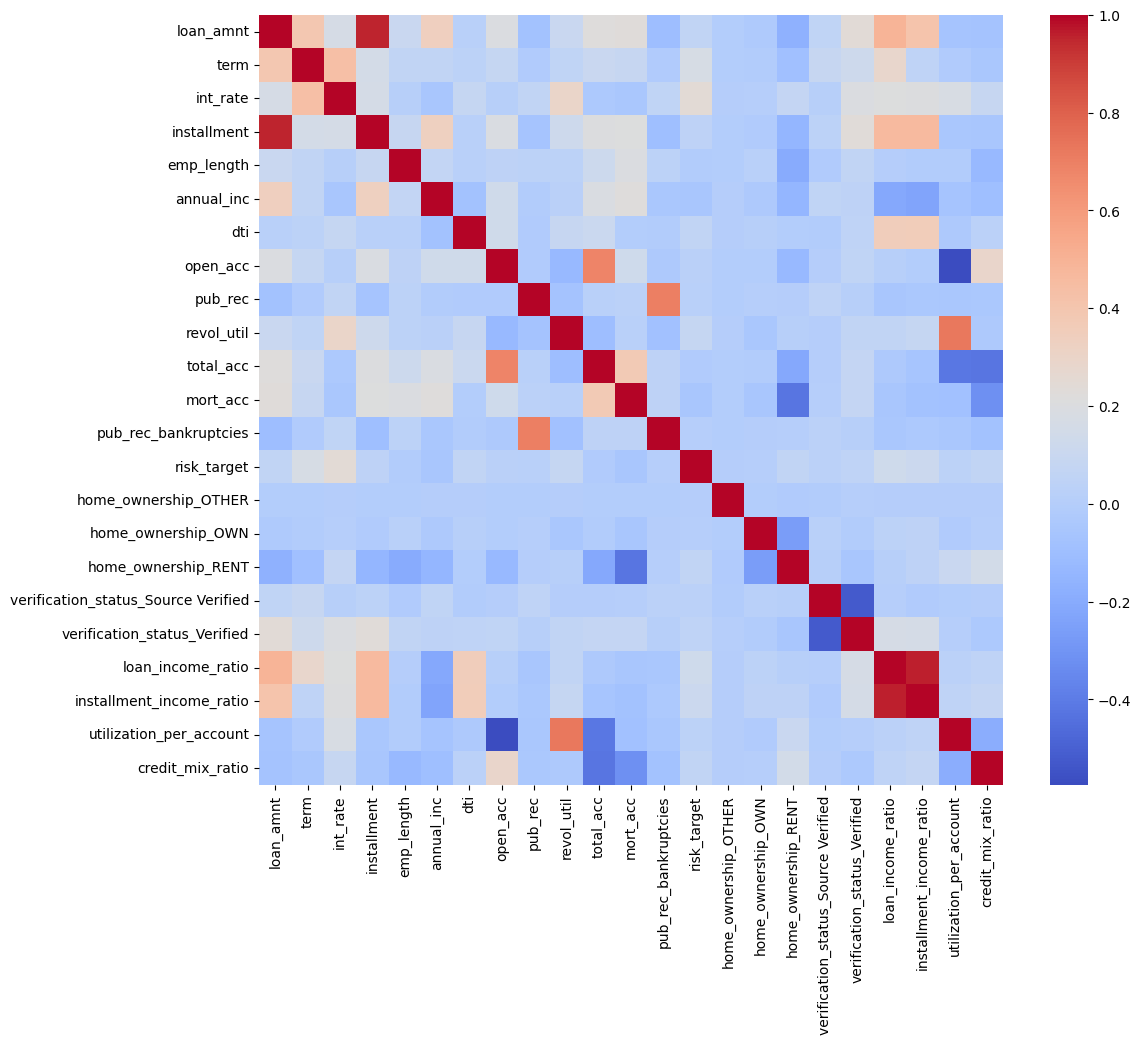

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 23 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            396030 non-null  float64
 1   term                                 396030 non-null  int64  
 2   int_rate                             396030 non-null  float64
 3   installment                          396030 non-null  float64
 4   emp_length                           396030 non-null  float64
 5   annual_inc                           396030 non-null  float64
 6   dti                                  396030 non-null  float64
 7   open_acc                             396030 non-null  float64
 8   pub_rec                              396030 non-null  float64
 9   revol_util                           396030 non-null  float64
 10  total_acc                            396030 non-null  float64
 11  mort_acc     

In [39]:
(df['annual_inc'] == 0).sum()

np.int64(1)

In [40]:
df['annual_inc'] = df['annual_inc'].replace(0, 1)

In [41]:
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']
df['installment_income_ratio'] = df['installment'] / df['annual_inc']

In [42]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [43]:
np.isinf(df).sum().sum()
df.isnull().sum().sum()

np.int64(0)

# Apply Models

In [44]:
X = df.drop('risk_target', axis=1)
y = df['risk_target']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
#model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [48]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [49]:
from sklearn.metrics import roc_auc_score, classification_report

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

y_pred = (y_proba > 0.4).astype(int)
#y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7040423357930412
              precision    recall  f1-score   support

           0       0.91      0.45      0.60     63671
           1       0.27      0.81      0.40     15535

    accuracy                           0.52     79206
   macro avg       0.59      0.63      0.50     79206
weighted avg       0.78      0.52      0.56     79206



# Calculate Financial Scores

In [50]:
import numpy as np

score = 850 - (y_proba * 550)

In [51]:
results = X_test.copy()
results['Actual_Default'] = y_test.values
results['Probability_of_Default'] = y_proba
results['Financial_Score'] = score

In [52]:
results['Risk_Category'] = pd.cut(
    results['Financial_Score'],
    bins=[300, 580, 700, 850],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

In [53]:
results.groupby('Risk_Category')['Actual_Default'].mean()

/tmp/ipykernel_9607/525396665.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby('Risk_Category')['Actual_Default'].mean()


,Actual_Default
Risk_Category,
High Risk,0.309132
Medium Risk,0.138653
Low Risk,0.055986


# RandomForest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [55]:
rf_y_proba = rf_model.predict_proba(X_test)[:, 1]

In [56]:
rf_y_pred = (rf_y_proba > 0.5).astype(int)

In [57]:
from sklearn.metrics import roc_auc_score, classification_report

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_y_proba))
print(classification_report(y_test, rf_y_pred))

Random Forest ROC-AUC: 0.7078172034358087
              precision    recall  f1-score   support

           0       0.88      0.66      0.76     63671
           1       0.32      0.64      0.42     15535

    accuracy                           0.66     79206
   macro avg       0.60      0.65      0.59     79206
weighted avg       0.77      0.66      0.69     79206



In [58]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                                Feature  Importance
2                              int_rate    0.383435
1                                  term    0.130825
18                    loan_income_ratio    0.083176
6                                   dti    0.080377
19             installment_income_ratio    0.064687
5                            annual_inc    0.044814
9                            revol_util    0.033709
21                     credit_mix_ratio    0.027663
3                           installment    0.025893
0                             loan_amnt    0.023332
20              utilization_per_account    0.022509
15                  home_ownership_RENT    0.018465
11                             mort_acc    0.015262
10                            total_acc    0.012558
7                              open_acc    0.011472
4                            emp_length    0.007738
16  verification_status_Source Verified    0.003930
8                               pub_rec    0.003740
17         v

# Xgboost

In [59]:
!pip install xgboost

In [60]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [61]:
xgb_y_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_y_pred = (xgb_y_proba > 0.5).astype(int)

In [62]:
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_y_proba))
print(classification_report(y_test, xgb_y_pred))

XGBoost ROC-AUC: 0.7140324843478325
              precision    recall  f1-score   support

           0       0.89      0.66      0.76     63671
           1       0.32      0.66      0.43     15535

    accuracy                           0.66     79206
   macro avg       0.60      0.66      0.59     79206
weighted avg       0.78      0.66      0.69     79206



In [63]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_y_proba),
        roc_auc_score(y_test, xgb_y_proba)
    ]
})

print(comparison)

                 Model   ROC_AUC
0  Logistic Regression  0.704042
1        Random Forest  0.707817
2              XGBoost  0.714032


In [64]:
xgb_score = 850 - (xgb_y_proba * 550)
xgb_results = X_test.copy()
xgb_results['Actual_Default'] = y_test.values
xgb_results['Probability_of_Default'] = xgb_y_proba
xgb_results['Financial_Score'] = xgb_score

In [65]:
xgb_results['Risk_Category'] = pd.cut(
    xgb_results['Financial_Score'],
    bins=[300, 580, 700, 850],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

In [93]:
print(
    xgb_results.groupby('Risk_Category')['Actual_Default'].mean().round(3).reset_index()
)

  Risk_Category  Actual_Default
0     High Risk           0.313
1   Medium Risk           0.137
2      Low Risk           0.059


/tmp/ipykernel_9607/3737979340.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xgb_results.groupby('Risk_Category')['Actual_Default'].mean().round(3).reset_index()


In [67]:
print(xgb_results[['Probability_of_Default', 'Financial_Score', 'Risk_Category']].head(20))

        Probability_of_Default  Financial_Score Risk_Category
111897                0.314021       677.288696   Medium Risk
273798                0.561023       541.437500     High Risk
34045                 0.703138       463.274109     High Risk
83809                 0.233903       721.353149      Low Risk
279718                0.606704       516.312927     High Risk
162031                0.354742       654.891907   Medium Risk
357793                0.618681       509.725708     High Risk
59172                 0.264939       704.283264      Low Risk
225508                0.554226       545.175781     High Risk
101331                0.426554       615.395203   Medium Risk
230886                0.477078       587.606934   Medium Risk
269061                0.620772       508.575592     High Risk
127161                0.713577       457.532837     High Risk
295973                0.119261       784.406555      Low Risk
136125                0.443607       606.016174   Medium Risk
290680  

# Clustering

# K-Means

In [68]:
#Generate probabilities for FULL dataset
xgb_full_proba = xgb_model.predict_proba(X)[:, 1]

In [69]:
#Convert to financial score
xgb_full_score = 850 - (xgb_full_proba * 550)

In [70]:
#Create clustering dataset
cluster_features = [
    'annual_inc',
    'dti',
    'revol_util',
    'loan_income_ratio',
    'credit_mix_ratio'
]

X_cluster = df[cluster_features].copy()

In [71]:
#Add financial score
X_cluster['Financial_Score'] = xgb_full_score

In [72]:
#Handle missing values
import numpy as np

X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.dropna()

In [73]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [74]:
#Apply K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [75]:
#Add cluster labels
X_cluster['Cluster'] = clusters

In [76]:
X_cluster = X_cluster[X_cluster['dti'] < 100]  # remove extreme outliers

In [77]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_cluster['Cluster'] = le.fit_transform(X_cluster['Cluster'])

In [78]:
#Analyze clusters
print(X_cluster.groupby('Cluster').mean())

           annual_inc        dti  revol_util  loan_income_ratio  \
Cluster                                                           
0        63023.520569  20.157211   64.392071           0.246379   
1        86841.534826  14.172533   41.812972           0.175861   

         credit_mix_ratio  Financial_Score  
Cluster                                     
0                0.511396       531.196899  
1                0.398291       681.811890  


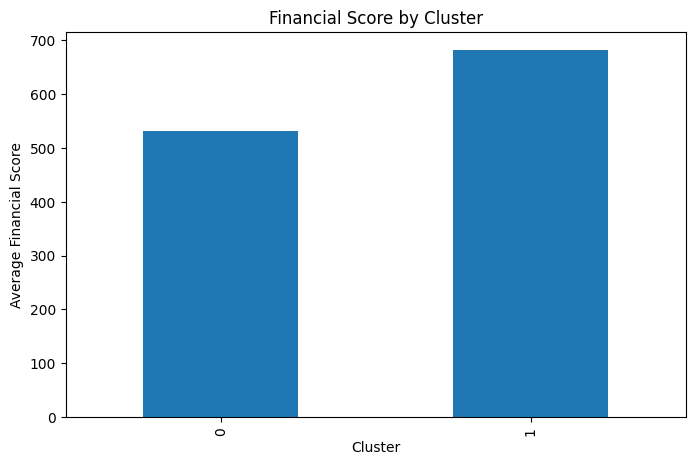

In [79]:
#Graph: Cluster vs Financial Score
import matplotlib.pyplot as plt

# Calculate average score per cluster
cluster_scores = X_cluster.groupby('Cluster')['Financial_Score'].mean()

# Plot
plt.figure(figsize=(8,5))
cluster_scores.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Average Financial Score")
plt.title("Financial Score by Cluster")

plt.show()

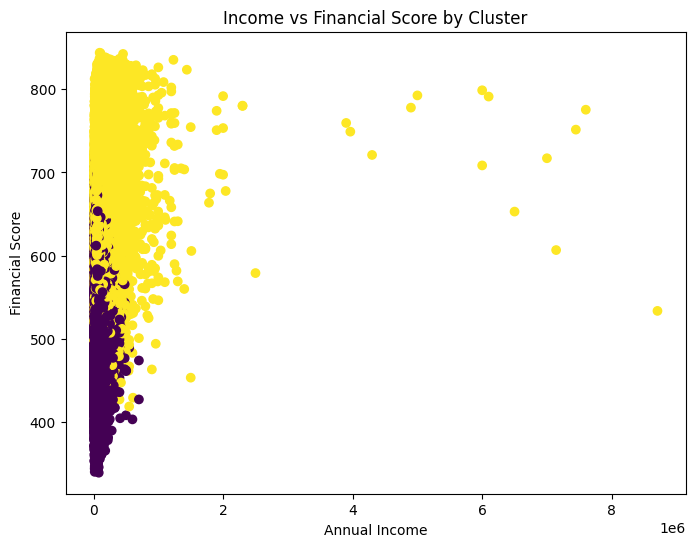

In [80]:
#Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_cluster['annual_inc'],
    X_cluster['Financial_Score'],
    c=X_cluster['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Financial Score")
plt.title("Income vs Financial Score by Cluster")

plt.show()

# 🤖 AI Financial Assistant: Explain Scores, Risk & Model Insights

In [81]:
!pip install google-generativeai

In [82]:
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
#print(api_key)  # just to verify (optional)

In [83]:
import google.generativeai as genai

genai.configure(api_key=api_key)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [84]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2

In [85]:
model = genai.GenerativeModel("gemini-flash-latest")

In [86]:
response = model.generate_content("Explain credit risk in simple terms")
print(response.text)

At its simplest, **credit risk** is the possibility that a borrower will not pay back a loan.

Think of it as the **"risk of being stood up"** by someone who owes you money.

Here is a breakdown of how it works in plain English:

### 1. The Friend Analogy
Imagine you have two friends who both want to borrow $100:

*   **Friend A** has a steady job, always pays for dinner, and has never owed you a dime. Lending to them is **low credit risk**.
*   **Friend B** is currently unemployed, owes three other people money, and often "forgets" his wallet. Lending to them is **high credit risk**.

In both cases, there is a "risk" that you won't get your $100 back. That risk is higher with Friend B.

### 2. How do lenders measure this?
Banks and credit card companies aren't your friends, so they use data to figure out how risky you are. They look at three main things:

*   **Your History (Credit Score):** Have you paid people back on time in the past?
*   **Your Capacity:** Do you make enough money

In [87]:
project_context = f"""
Project: AI Financial Risk Intelligence System

Dataset: Lending Club Loan Dataset

Models Used:
- Logistic Regression: ROC-AUC = 0.704
- Random Forest: ROC-AUC = 0.707
- XGBoost: ROC-AUC = 0.714

Best Model: XGBoost

Financial Score:
- Calculated from probability of default
- Range: 300 to 850
- Higher score = lower risk

Clustering:
- K-Means (3 clusters)

Cluster 0:
- Score ~ 688 → Low Risk

Cluster 1:
- Score ~ 630 → Medium Risk

Cluster 2:
- Score ~ 517 → High Risk

Features Used:
income, dti, credit utilization, loan ratios, credit mix

Project Goal:
Predict credit risk, generate financial score, and segment users.
"""

In [88]:
def ask_llm(question):
    prompt = f"""
You are an AI Financial Assistant.

Use the following project context to answer the question.

{project_context}

User Question:
{question}

Answer clearly and professionally.
"""

    response = model.generate_content(prompt)
    return response.text

In [89]:
print(ask_llm("Which model is performing best?"))

Based on the project evaluation, the **XGBoost** model is the best-performing model.

It achieved an **ROC-AUC score of 0.714**, which outperforms both the Random Forest (0.707) and Logistic Regression (0.704) models. Due to its superior predictive accuracy, XGBoost was selected as the primary model for generating the financial risk scores and segmenting users in this system.


In [90]:
while True:
    question = input("Ask your question (type 'exit' to stop): ")

    if question.lower() == "exit":
        break

    answer = ask_llm(question)
    print("\nAI Answer:\n", answer)

Ask your question (type 'exit' to stop): Which model is best?

AI Answer:
 Based on the performance metrics of the **AI Financial Risk Intelligence System**, the best model is **XGBoost**.

It outperformed the other models evaluated with the highest **ROC-AUC score of 0.714**. For comparison:
*   **XGBoost:** 0.714 (Best performing)
*   **Random Forest:** 0.707
*   **Logistic Regression:** 0.704

The XGBoost model serves as the core engine for this system, providing the probability of default used to calculate financial scores and segment users into risk clusters.
Ask your question (type 'exit' to stop): exit


# Here are some questions you can ask llm

In [ ]:
#Which model is best?
#Why XGBoost is better?
#Explain ROC-AUC
#Why accuracy dropped after threshold change?
#What do clusters represent?
#Which cluster is risky?
#Why income doesn’t decide score?
#What is this project about?
#Advantages of this system?
#Where is it used?
#How does it work?